<a href="https://colab.research.google.com/github/nileshgarg-tech/mortgage-ai-document-intelligence/blob/main/Cleaning_a_blurry_image.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# We are trying to clean this image and learn basics of image processing along the way

In [2]:
# Loading Essential Libraries
import cv2
import numpy as np
from PIL import Image
from google.colab.patches import cv2_imshow
from google.colab import files
import requests
from io import BytesIO

In [3]:
image_address = "/content/noisy_image_sample.jpg"

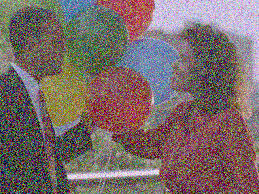

In [4]:
# OpenCV: Load & display an image
img_cv = cv2.imread(image_address)  # Read image
cv2_imshow(img_cv)  # Show image

NumPy Image Shape: (194, 259, 3)


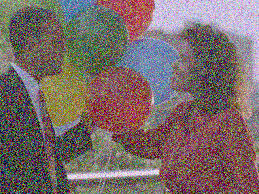

In [5]:
# PIL (Pillow): Load & display an image
img_pil = Image.open(image_address)
# NumPy: Convert image to array and print shape
img_np = np.array(img_pil)
print("NumPy Image Shape:", img_np.shape)

display(img_pil)

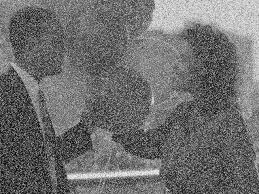

In [14]:
gray = cv2.cvtColor(img_cv, cv2.COLOR_BGR2GRAY)
cv2_imshow(gray)

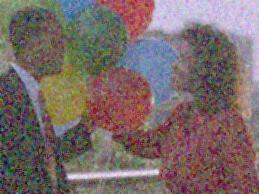

In [17]:
# ksize must be an odd number > 1
median_cleaned = cv2.medianBlur(img_cv, 3)
cv2_imshow(median_cleaned)

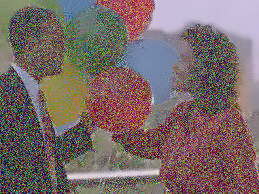

In [16]:
# h=10 is usually a good starting point for colored images
nlm_denoised = cv2.fastNlMeansDenoisingColored(img_cv, None, h=10, hColor=10, templateWindowSize=7, searchWindowSize=21)
cv2_imshow(nlm_denoised)

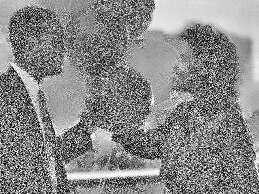

In [18]:
# Convert to grayscale first for CLAHE
gray_denoised = cv2.cvtColor(nlm_denoised, cv2.COLOR_BGR2GRAY)
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
final_result = clahe.apply(gray_denoised)

cv2_imshow(final_result)

In [19]:
cv2.imwrite('final_processed_image.jpg', final_result)

True

In [20]:
print("Image saved successfully as 'final_processed_image.jpg'")

Image saved successfully as 'final_processed_image.jpg'
